In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 전체 데이터 및 피처 확인

In [2]:
#데이터 불러오기
df = pd.read_csv("dataset/Crop_Yeild_Data.csv")
#데이터 피처 확인
df.head()


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [3]:
# 독립 변수와 종속 변수 설정
# 독립 변수
X = df.drop('Production',axis=1)
# 종속 변수
y = df['Production']

# 범주형 및 정제된 수치형 컬럼 리스트 분류
categorical_cols = ['Crop','Season','State']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print(f"\n범주형 변수 목록:{categorical_cols}")
print(f"\n수치형 변수 목록:{numeric_cols}")


범주형 변수 목록:['Crop', 'Season', 'State']

수치형 변수 목록:['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


In [4]:
# 데이터 구조 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  str    
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  str    
 3   State            19689 non-null  str    
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), str(3)
memory usage: 2.5 MB


In [5]:
# 데이터 이상치 확인 
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755186,2.410331e+07,4.884835e+04,79.954011,23.831279,33.947314,14.723357
std,6.498099,7.328287e+05,2.630568e+08,816.909592,9.494600e+07,2.132874e+05,878.306194,5.847672,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000,-5.115000,7.701000,-19.359000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000,23.545000,32.483000,13.535000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000,25.675000,35.826000,15.890000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.389000,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000,28.652000,40.632000,24.972000


In [6]:
#컬럼별 결측치 개수 확인
print(df.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64


In [7]:
# 중복 데이터 확인
print(df.duplicated().sum())

0


## EDA (탐색적 데이터 분석)

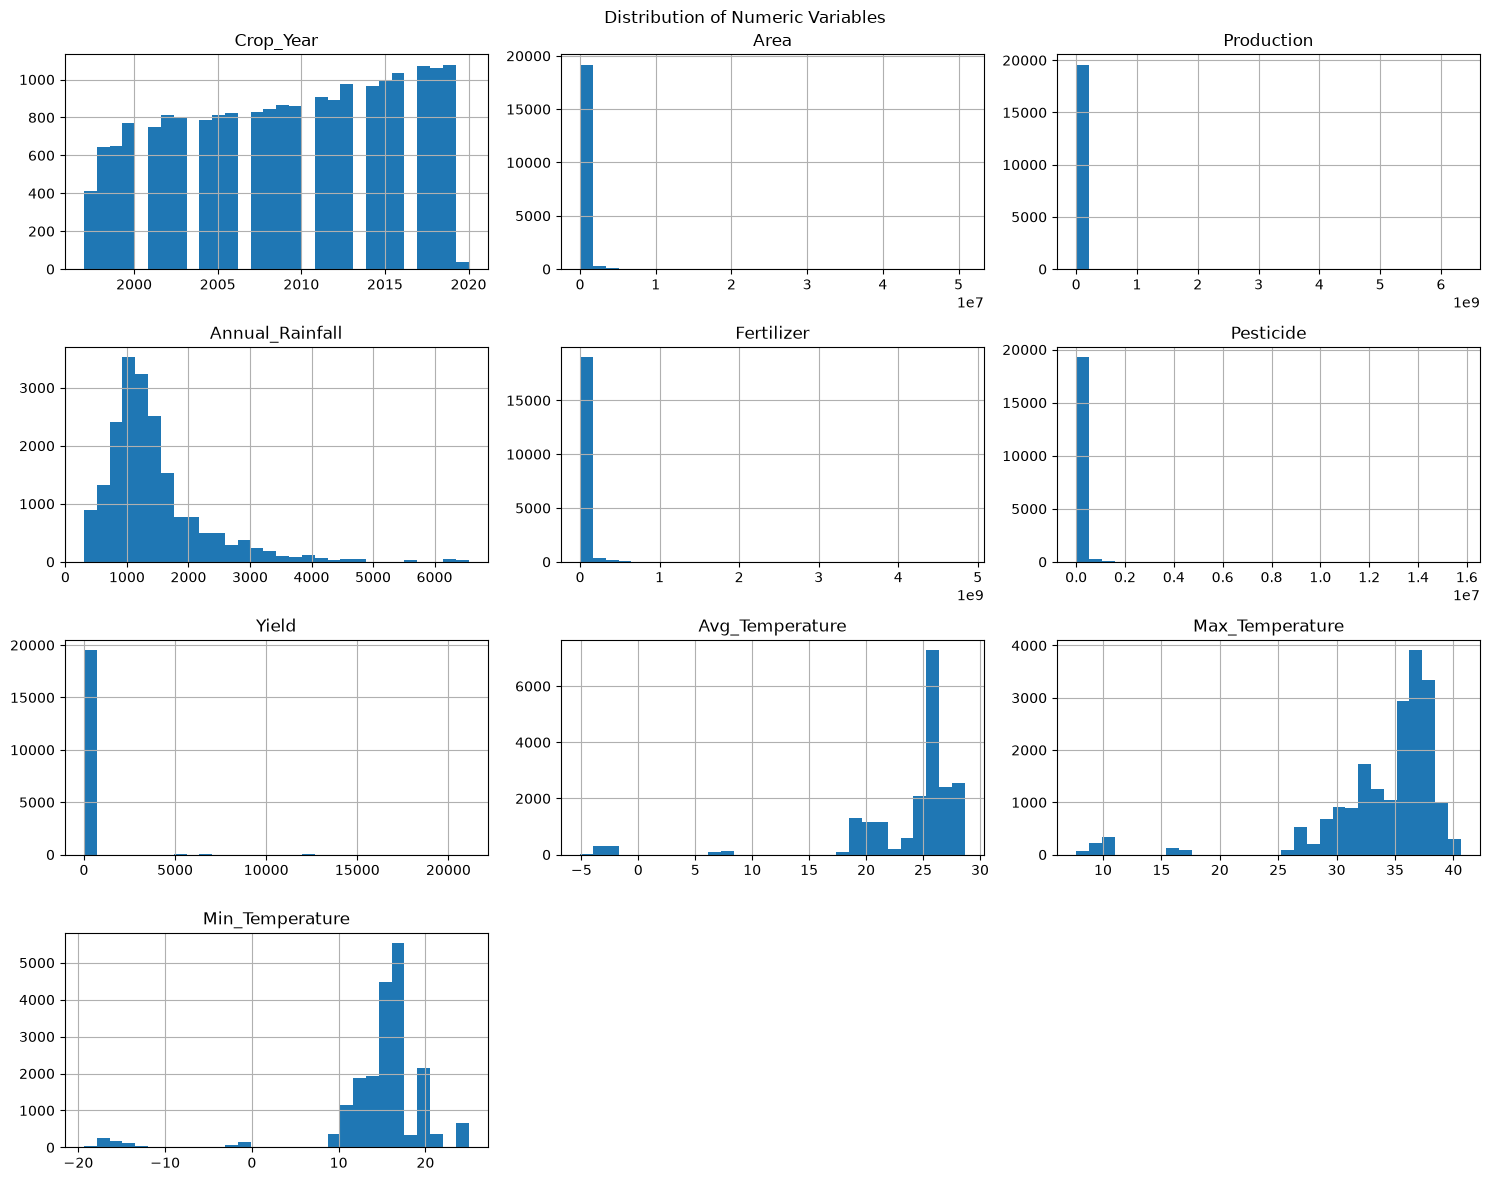

In [8]:
# 수치형 변수만
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 변수별 히스토그램
df[numeric_cols].hist(figsize=(15, 12), bins=30)

plt.suptitle('Distribution of Numeric Variables')
plt.tight_layout()
plt.show()

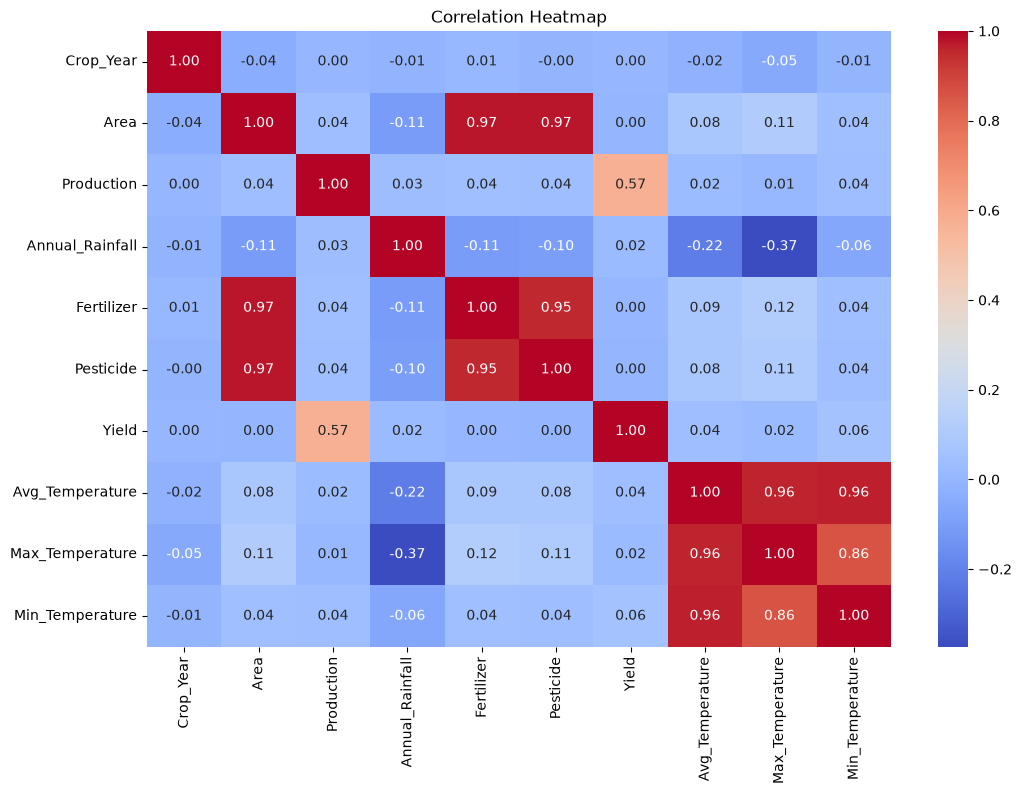

In [9]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

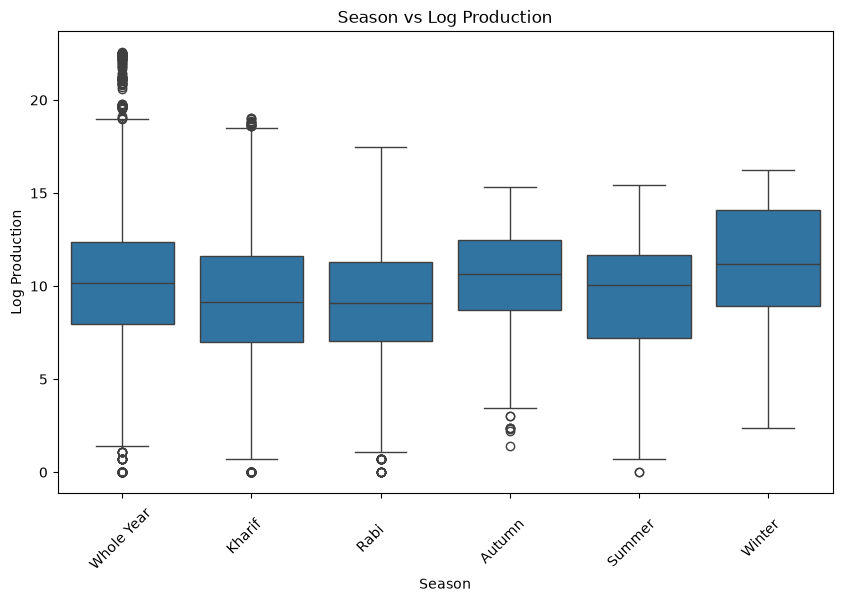

In [10]:
df['log_Production'] = np.log1p(df['Production'])

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Season',
    y='log_Production'
)

plt.title('Season vs Log Production')
plt.xlabel('Season')
plt.ylabel('Log Production')
plt.xticks(rotation=45)

plt.show()

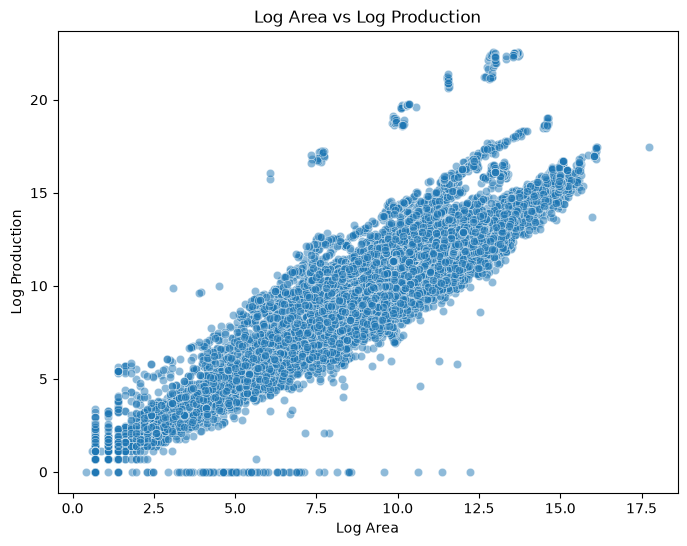

In [11]:


# EDA용 로그 변환
df['log_Area'] = np.log1p(df['Area'])
df['log_Production'] = np.log1p(df['Production'])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='log_Area',
    y='log_Production',
    alpha=0.5
)

plt.title('Log Area vs Log Production')
plt.xlabel('Log Area')
plt.ylabel('Log Production')

plt.show()

## 데이터 전처리

In [12]:
# 모델링에 사용할 데이터 복사
model_df = df.copy()

# EDA에서 만든 임시 컬럼 제거
model_df = model_df.drop(
    columns=['log_Area', 'log_Production'],
    errors='ignore'
)

# Yield는 Production 정보가 포함될 수 있으므로 제외
X = model_df.drop(['Production', 'Yield','Crop_Year','Season'], axis=1)
y = model_df['Production']

In [16]:
# 독립변수 / 종속변수
X = df.drop(
    ['Production', 'Yield', 'Crop_Year','Season','log_Production', 'log_Area'],
    axis=1,
    errors='ignore'
)

y = df['Production']

# 범주형 변수
categorical_cols = ['Crop','State']

# 수치형 변수 다시 설정 ★
numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print("범주형:", categorical_cols)
print("수치형:", numeric_cols)

범주형: ['Crop', 'State']
수치형: ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


## 피처 엔지니어링

## X,y 분리 및 데이터 분리

In [17]:
# 데이터 분할 
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.2,random_state=42)

In [18]:

# 인코딩
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first')

# 학습 데이터의 범주형 변수 피팅 및 변환
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# 인코딩된 컬럼명 얻기
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)

# 수치형 변수와 결합해서 새로운 데이터 프레임 생성
X_train_encoded = pd.concat([
    X_train[numeric_cols].reset_index(drop=True),
    pd.DataFrame(X_train_cat,columns=encoded_cat_cols)
],axis=1)

X_test_encoded = pd.concat([
    X_test[numeric_cols].reset_index(drop=True),
    pd.DataFrame(X_test_cat,columns=encoded_cat_cols)
],axis=1)

# 데이터 스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


c:\Users\human-09\Downloads\project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [19]:
# 모델 학습
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

model.fit(X_train_scaled, y_train)

# 예측
y_pred = model.predict(X_test_scaled)

# 평가
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 2367210.416206831
RMSE: 41991423.09812647
R² : 0.9752523515352256


In [20]:
# 학습 데이터 예측
y_train_pred = model.predict(X_train_scaled)

# Train / Test R² 비교
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R² :", train_r2)
print("Test R²  :", test_r2)
print("Gap      :", train_r2 - test_r2)
   

Train R² : 0.9893651853680692
Test R²  : 0.9752523515352256
Gap      : 0.014112833832843563


In [21]:


models = {
    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)

Linear Regression
MAE : 36319389.48079167
RMSE: 204112548.23730218
R²  : 0.41527432856535296
Random Forest
MAE : 2367210.416206831
RMSE: 41991423.09812647
R²  : 0.9752523515352256
XGBoost
MAE : 2740861.5
RMSE: 58767347.973931514
R²  : 0.9515286684036255


In [22]:
# Random Forest 다시 선택
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train_scaled, y_train)

# 피처 중요도
importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

print(importance)

              Feature  Importance
15      Crop_Coconut     0.397939
2          Fertilizer    0.334572
0                Area    0.151748
3           Pesticide    0.054990
1     Annual_Rainfall    0.023959
6     Min_Temperature    0.016949
71    State_Karnataka    0.005840
4     Avg_Temperature    0.004753
5     Max_Temperature    0.004202
83   State_Tamil Nadu    0.003849
88  State_West Bengal    0.000909
51     Crop_Sugarcane    0.000251
72       State_Kerala    0.000026
80   State_Puducherry    0.000008
42        Crop_Potato    0.000002


In [23]:

importance_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)
season_features = importance_df[
    importance_df['Feature'].str.startswith('Season_Whole Year')
]

print(season_features)
print("Season 전체 중요도:", season_features['Importance'].sum())

Empty DataFrame
Columns: [Feature, Importance]
Index: []
Season 전체 중요도: 0.0


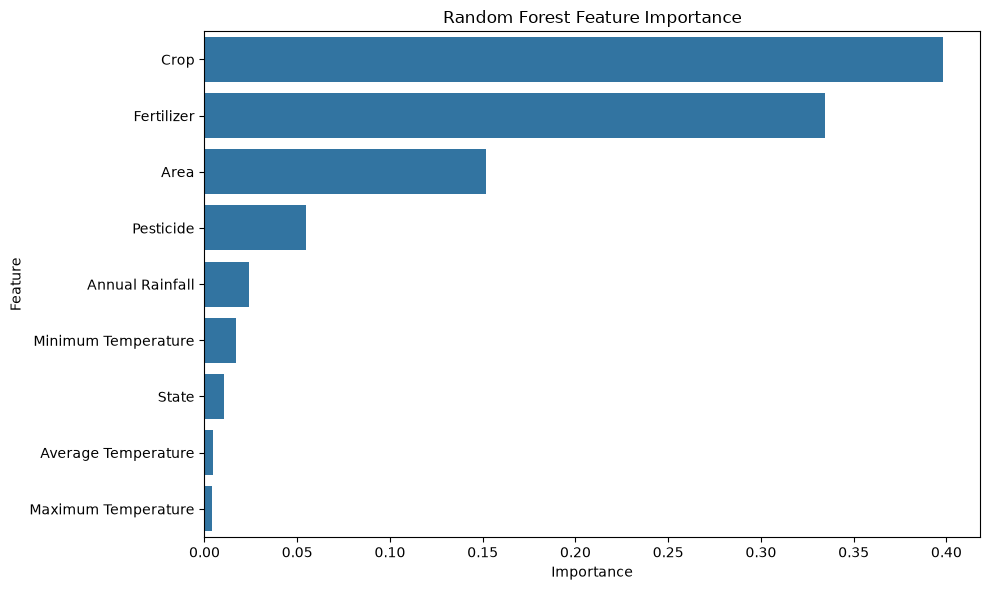

In [39]:
feature_names = list(scaler.feature_names_in_)

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})


def group_feature(feature):

    if feature.startswith('Crop_'):
        return 'Crop'

    elif feature.startswith('State_'):
        return 'State'

    elif feature == 'Area':
        return 'Area'

    elif feature == 'Annual_Rainfall':
        return 'Annual Rainfall'

    elif feature == 'Fertilizer':
        return 'Fertilizer'

    elif feature == 'Pesticide':
        return 'Pesticide'

    elif feature == 'Avg_Temperature':
        return 'Average Temperature'

    elif feature == 'Max_Temperature':
        return 'Maximum Temperature'

    elif feature == 'Min_Temperature':
        return 'Minimum Temperature'

    else:
        return feature


importance['Feature_Group'] = importance['Feature'].apply(group_feature)


grouped_importance = (
    importance
    .groupby('Feature_Group')['Importance']
    .sum()
    .reset_index()
    .sort_values('Importance', ascending=False)
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=grouped_importance,
    x='Importance',
    y='Feature_Group'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [32]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train_scaled, y_train)


joblib.dump(rf_model, 'crop_model.joblib')
joblib.dump(encoder, 'encoder.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [31]:
print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>
